In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")

print(merged.shape)
print("deltav_km_s" in merged.columns)  # should print True
merged[['OBJECT_NAME', 'altitude_km', 'deltav_km_s', 'attr_mass']].dropna().head(10)

(66727, 57)
True


,OBJECT_NAME,altitude_km,deltav_km_s,attr_mass
1,VANGUARD 1,2958.830356,0.5940,1.46
3,EXPLORER 4,253.542836,0.0158,17.34
4,VANGUARD 2,2363.038666,0.4956,9.71
5,VANGUARD R/B,3259.266791,0.6392,22.79
7,VANGUARD R/B,2319.550481,0.4879,22.79
11,VANGUARD 3,2153.773720,0.4578,67.39
12,EXPLORER 7,512.094993,0.0888,41.13
18,TIROS 1,629.312944,0.1203,118.93
20,TRANSIT 1B,228.633602,0.0085,119.92
33,MIDAS 2 DEB,236.262788,0.0107,19.82


In [2]:
# hall thrusters
# powered by solar panels [ no harmful emissions]
ISP = 2000      # specific impulse of hall thruster (seconds)
G0 = 0.00981    # standard gravity (km/s2)

# tsiolkovsky rocket equation
# dv = isp * g0 * ln(m0/mf)
# solving for xenon mass needed

def expellant_needed(dry_mass_kg, dv_km_s):
    if pd.isna(dry_mass_kg) or pd.isna(dv_km_s):
        return np.nan
    if dry_mass_kg <= 0 or dv_km_s <= 0:
        return np.nan
    
    mass_ratio = np.exp(dv_km_s / (ISP * G0))
    expellant_mass = dry_mass_kg * (mass_ratio - 1)
    return round(expellant_mass, 3)

merged['attr_mass'] = pd.to_numeric(merged['attr_mass'], errors='coerce')
merged['expellant_mass_kg'] = merged.apply(
    lambda row: expellant_needed(row['attr_mass'], row['deltav_km_s']), axis=1
)

print("expellant mass calculated for", merged['expellant_mass_kg'].notna().sum(), "objects")
merged[['OBJECT_NAME', 'attr_mass', 'deltav_km_s', 'expellant_mass_kg']].dropna().head(10)

expellant mass calculated for 20133 objects


,OBJECT_NAME,attr_mass,deltav_km_s,expellant_mass_kg
1,VANGUARD 1,1.46,0.5940,0.045
3,EXPLORER 4,17.34,0.0158,0.014
4,VANGUARD 2,9.71,0.4956,0.248
5,VANGUARD R/B,22.79,0.6392,0.755
7,VANGUARD R/B,22.79,0.4879,0.574
11,VANGUARD 3,67.39,0.4578,1.591
12,EXPLORER 7,41.13,0.0888,0.187
18,TIROS 1,118.93,0.1203,0.731
20,TRANSIT 1B,119.92,0.0085,0.052
33,MIDAS 2 DEB,19.82,0.0107,0.011


In [3]:
# xenon as % of total mass — lighter is better
merged['expellant_percent'] = (merged['expellant_mass_kg'] / merged['attr_mass']) * 100

print(merged[['expellant_mass_kg', 'expellant_percent']].dropna().describe())
print("\nleast expellant needed (easiest to deorbit):")
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'attr_mass', 'expellant_mass_kg', 'risk_label']].dropna().sort_values('expellant_mass_kg').head(10)

       expellant_mass_kg  expellant_percent
count       20133.000000       20133.000000
mean           29.866784           1.745685
std            83.494911           2.581318
min             0.000000           0.000000
25%             1.303000           0.418261
50%             2.417000           0.507541
75%             6.964000           1.322973
max          2555.517000           7.866667

least expellant needed (easiest to deorbit):


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,expellant_mass_kg,risk_label
55101,OBJECT AX,UNKNOWN,3.697986e+02,0.125,0.000,HIGH
60029,OBJECT W,UNKNOWN,2.986801e+02,0.250,0.000,HIGH
54983,OBJECT AR,UNKNOWN,7.466404e+11,2.010,0.000,HIGH
44787,AC 10A PROBE (GOLF),PAYLOAD,3.833215e+02,0.016,0.000,LOW
3469,SCOUT B DEB,DEBRIS,2.292249e+02,1.000,0.000,LOW
54717,FOSSASAT2E15 (FEROX),PAYLOAD,3.734414e+13,2.000,0.000,HIGH
48923,HADES,PAYLOAD,2.828387e+13,0.375,0.000,HIGH
52168,ASTROCAST-0301,PAYLOAD,6.073670e+12,4.500,0.000,HIGH
43048,AC 10A PROBE (GANGESTAD),PAYLOAD,2.882254e+02,0.016,0.000,LOW
60301,OBJECT CL,UNKNOWN,4.610693e+02,0.250,0.001,MEDIUM


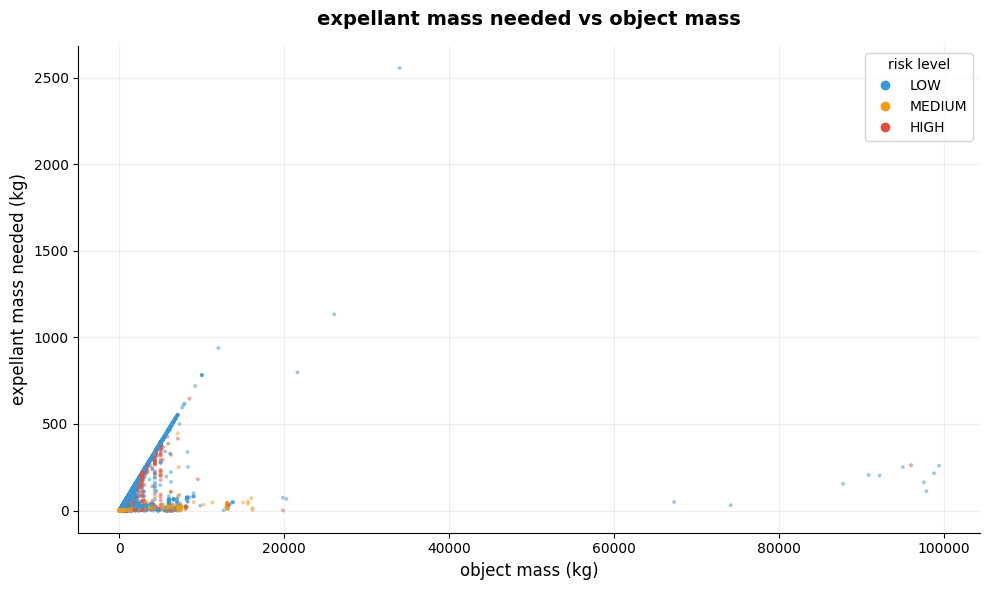

In [4]:
# expellant vs object mass — heavier objects need more expellant obviously
fig, ax = plt.subplots(figsize=(10, 6))

sample = merged[(merged['attr_mass'].between(1, 100000)) & 
                (merged['expellant_mass_kg'].between(0, 5000))].dropna(subset=['expellant_mass_kg', 'attr_mass'])

colors = sample['risk_label'].map({'LOW': '#3498db', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'})

ax.scatter(sample['attr_mass'], sample['expellant_mass_kg'],
           c=colors, s=8, alpha=0.5, edgecolors='none')

ax.set_title('expellant mass needed vs object mass', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('object mass (kg)', fontsize=12)
ax.set_ylabel('expellant mass needed (kg)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='LOW'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markersize=8, label='MEDIUM'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='HIGH'),
]
ax.legend(handles=legend, title='risk level')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3247/3952792143.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_expellant = merged.groupby('regime')['expellant_mass_kg'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()


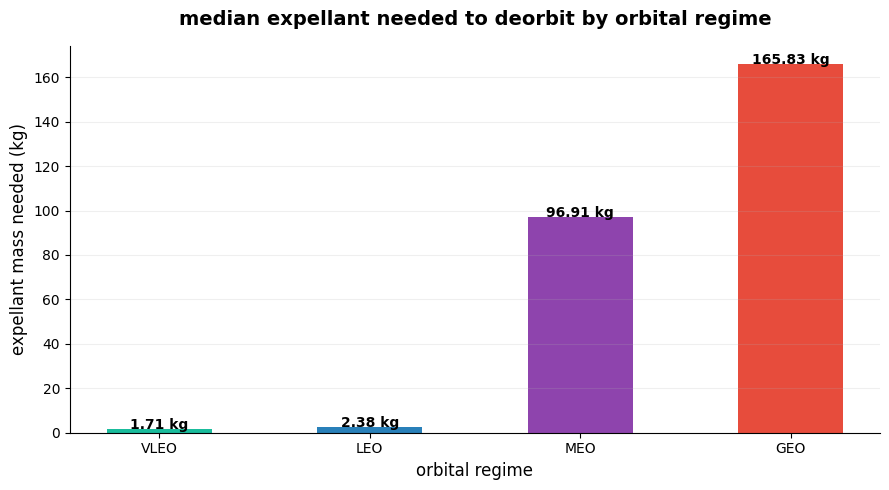

In [5]:
# median expellant needed per regime
fig, ax = plt.subplots(figsize=(9, 5))

regime_expellant = merged.groupby('regime')['expellant_mass_kg'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()
colors = ['#1abc9c', '#2980b9', '#8e44ad', '#e74c3c']

bars = ax.bar(regime_expellant.index, regime_expellant.values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, regime_expellant.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f} kg', ha='center', fontweight='bold', fontsize=10)

ax.set_title('median expellant needed to deorbit by orbital regime', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('orbital regime', fontsize=12)
ax.set_ylabel('expellant mass needed (kg)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
# most important — high risk objects and how much expellant to fix them
print("high risk objects and expellant needed:")
merged[merged['risk_label'] == 'HIGH'][['OBJECT_NAME', 'OBJECT_TYPE', 
    'altitude_km', 'attr_mass', 'deltav_km_s', 'expellant_mass_kg']].dropna().sort_values('expellant_mass_kg').head(15)

high risk objects and expellant needed:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,deltav_km_s,expellant_mass_kg
54717,FOSSASAT2E15 (FEROX),PAYLOAD,3.734414e+13,2.000,0.0001,0.000
55101,OBJECT AX,UNKNOWN,3.697986e+02,0.125,0.0492,0.000
48923,HADES,PAYLOAD,2.828387e+13,0.375,0.0001,0.000
52168,ASTROCAST-0301,PAYLOAD,6.073670e+12,4.500,0.0003,0.000
54983,OBJECT AR,UNKNOWN,7.466404e+11,2.010,0.0007,0.000
60029,OBJECT W,UNKNOWN,2.986801e+02,0.250,0.0289,0.000
56432,MDQUBESAT-2,PAYLOAD,3.990486e+02,0.500,0.0575,0.001
54822,OBJECT AR,UNKNOWN,1.328793e+12,42.000,0.0005,0.001
55104,OBJECT BA,UNKNOWN,3.881074e+02,0.250,0.0544,0.001
61086,HYDRA-W,PAYLOAD,3.704002e+02,0.375,0.0494,0.001


In [7]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with expellant data!!", merged.shape)

saved with expellant data!! (66727, 59)
